In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import zivot_andrews


In [4]:
df = pd.read_csv("data/processed/monthly_housing_clean.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df["hpi"] = pd.to_numeric(df["hpi"], errors="coerce")

# Log transformation and first differencing
df["log_hpi"] = np.log(df["hpi"])
df["diff_log_hpi"] = df["log_hpi"].diff()

# Remove NA after differencing
df_diff = df.dropna(subset=["diff_log_hpi"]).copy()

df_diff.head(3)

,date,hpi,numsold,log_hpi,diff_log_hpi
1,1991-02-01,100.48,40,4.609959,0.004789
2,1991-03-01,100.74,51,4.612543,0.002584
3,1991-04-01,100.75,50,4.612642,0.000099


### TS plot

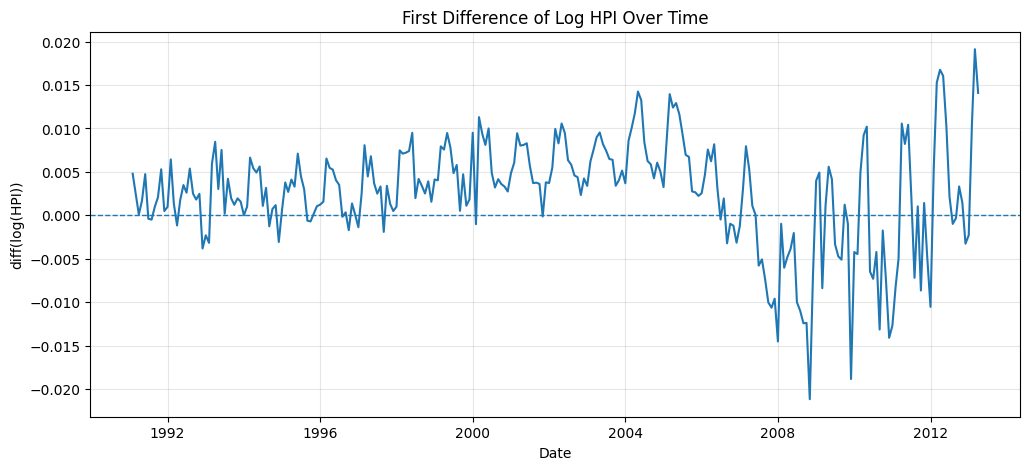

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df_diff["date"], df_diff["diff_log_hpi"])
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("First Difference of Log HPI Over Time")
plt.xlabel("Date")
plt.ylabel("diff(log(HPI))")
plt.grid(True, alpha=0.3)
plt.show()

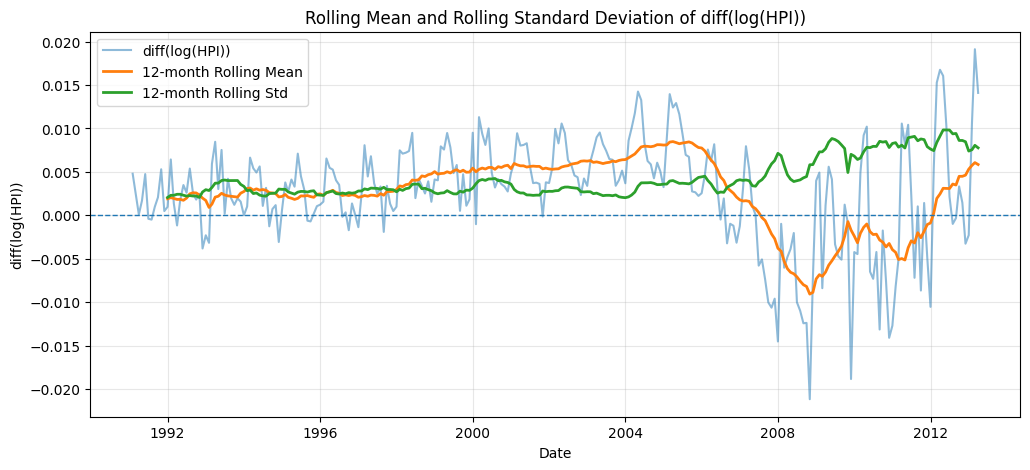

In [6]:
df_diff["rolling_mean_12"] = df_diff["diff_log_hpi"].rolling(window=12).mean()
df_diff["rolling_std_12"] = df_diff["diff_log_hpi"].rolling(window=12).std()

plt.figure(figsize=(12, 5))

plt.plot(df_diff["date"], df_diff["diff_log_hpi"], 
         label="diff(log(HPI))", alpha=0.5)

plt.plot(df_diff["date"], df_diff["rolling_mean_12"], 
         label="12-month Rolling Mean", linewidth=2)

plt.plot(df_diff["date"], df_diff["rolling_std_12"], 
         label="12-month Rolling Std", linewidth=2)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Rolling Mean and Rolling Standard Deviation of diff(log(HPI))")
plt.xlabel("Date")
plt.ylabel("diff(log(HPI))")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x500 with 0 Axes>

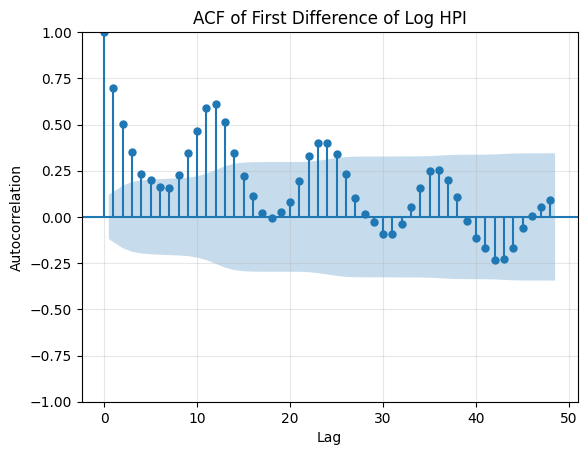

In [8]:
plt.figure(figsize=(10, 5))
plot_acf(df_diff["diff_log_hpi"], lags=48)

plt.title("ACF of First Difference of Log HPI")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
adf_result = adfuller(df_diff["diff_log_hpi"])

print("ADF Test for diff(log(HPI))")
print("--------------------------------")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Number of Lags Used: {adf_result[2]}")
print(f"Number of Observations: {adf_result[3]}")

print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Test for diff(log(HPI))
--------------------------------
ADF Statistic: -2.2868
p-value: 0.1763
Number of Lags Used: 16
Number of Observations: 250
Critical Values:
   1%: -3.4568
   5%: -2.8732
   10%: -2.5730
